In [2]:
%load_ext autoreload
%autoreload 2

import cv2
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.signal import savgol_filter

import sys
sys.path.append('../../src')
from utils import smooth_curve
from Viz import show_images
from PlumeDataset import plume_dataset
from AutoAlign import align_plumes
from Velocity import VelocityCalculator
from PlumeMetrics import PlumeMetrics


def analyze_function(plumes, threshold, index, x_range, plume_name, 
                     align_parms={'align':False, 'coords':None, 'coords_standard':None}):
    
    # align plumes
    if align_parms['align']:
        if align_parms['coords'] is None or align_parms['coords_standard'] is None:
            raise ValueError('Please provide the coordinates for alignment')
        else:
            plumes = align_plumes(plumes, align_parms['coords'], align_parms['coords_standard'])

    # ignore the frame=2,3 for accurate velocity calculation
    plumes[:, 2] = plumes[:, 1]
    plumes[:, 3] = plumes[:, 1]

    # show_images(plumes[0][:32], img_per_row=16, img_height=1, title=plume_name)

    # areas, coords, labeled_images = P.calculate_area_for_plumes(plumes, threshold=threshold, return_format='dataframe')
    # P.viz_blob_plume(plumes[index][x_range[0]:x_range[1]], areas[index][x_range[0]:x_range[1]], 
    #                 coords[index][x_range[0]:x_range[1]], labeled_images[index][x_range[0]:x_range[1]], title=f'{plume_name}-Area')
    # df_area = P.to_df(areas)

    plume_positions, plume_distances, plume_velocities = V.calculate_distance_area_for_plumes(plumes)
    V.visualize_plume_positions(plumes[index][x_range[0]: x_range[1]], plume_positions[index][x_range[0]: x_range[1]], 
                                label_time=False, title=f'{plume_name}-plume position')
    df_velocity = V.to_df(plume_positions, plume_distances, plume_velocities)
    # df = pd.concat([df_velocity, df_area], axis=1)
    df = df_velocity
    return df

plume_ds_2_25 = plume_dataset(file_path='../../datasets/PlumeMapping_2.25_YichenGuo_04112024.h5', group_name='PLD_Plumes')
plume_ds_1_75 = plume_dataset(file_path='../../datasets/PlumeMapping_1.75_YichenGuo_04122024.h5', group_name='PLD_Plumes')
plume_ds_1_25 = plume_dataset(file_path='../../datasets/PlumeMapping_1.25_YichenGuo_04122024.h5', group_name='PLD_Plumes')

# analysis frame parameters
coors_standard = np.array([[25,64], [27,199], [375,37], [375,220]])
start_position = ((25+27)//2, (64+199)//2)
position_range = (25+27)//2, 375
threshold = 50
time_interval = 500e-9  # 500ns

# visualize parameters
index = 3
x_range = (0, 32)

P = PlumeMetrics(time_interval, threshold=threshold)
V = VelocityCalculator(time_interval, position_range, start_position, threshold=threshold)

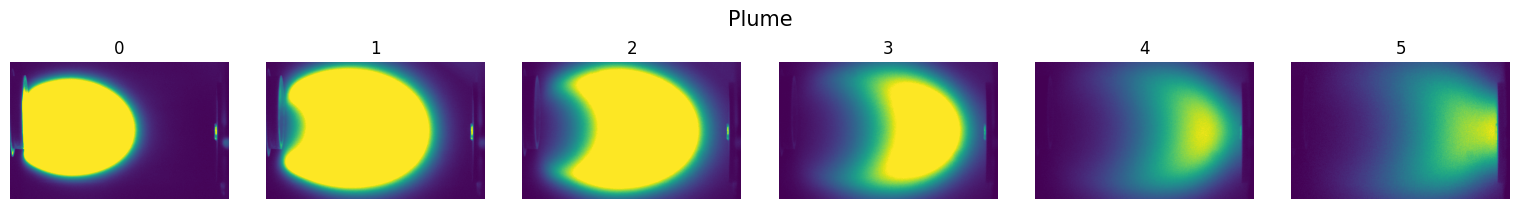

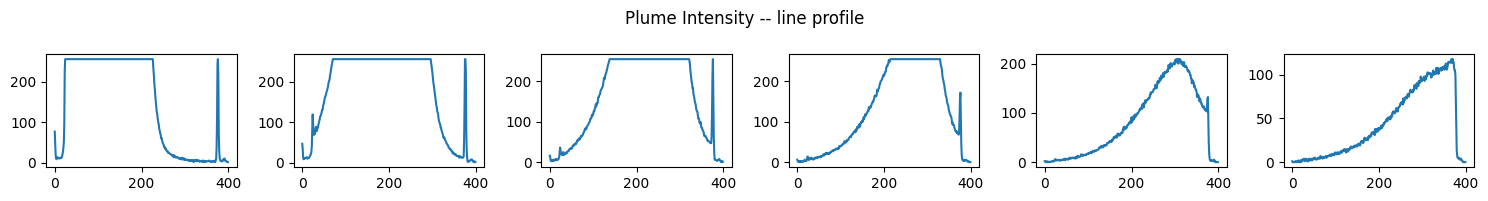

C:\Users\yig319\AppData\Local\Temp\ipykernel_5572\2050652831.py:40: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if intersection_x_coords != []:
C:\Users\yig319\AppData\Local\Temp\ipykernel_5572\2050652831.py:40: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  if intersection_x_coords != []:


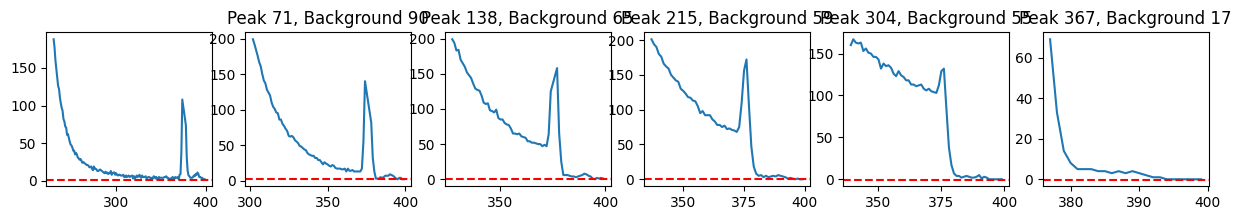

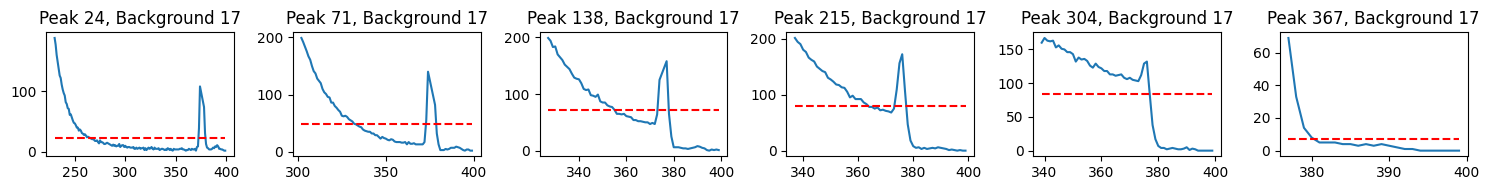

In [3]:
plumes = plume_ds_2_25.load_plumes('8-BaTiO3')
samples = plumes[0][6:28][::4]
show_images(samples, img_per_row=6, img_height=1, title='Plume')

lines = []
for img in samples:
    lines.append(img[(64+199)//2, :])
lines = np.array(lines)
fig, axes = plt.subplots(1, 6, figsize=(15, 2))
for ax, line in zip(axes.flatten(), lines):
    x = np.arange(len(line))
    ax.plot(line)
plt.suptitle('Plume Intensity -- line profile')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 6, figsize=(15, 2))
for ax, line in zip(axes.flatten(), lines):

    x_max = np.argmax(line)
    y_max = line[x_max]
    threshold = 0.8 * y_max

    x_ = x[x_max:]
    line_ = line[x_max:]

    below_threshold_indices = line_ < threshold
    x_ = x_[below_threshold_indices]
    line_ = line_[below_threshold_indices]

    smoothed_y = savgol_filter(line_, window_length=7, polyorder=2)
    background_estimate = np.min(smoothed_y)

    ax.plot(x_, line_)

    min_diff_indices = np.where(np.isclose(line_, background_estimate, atol=0.5))  # Adjust atol as needed
    intersection_x_coords = x[min_diff_indices]
    ax.axhline(y=background_estimate, color='r', linestyle='--')

    if intersection_x_coords != []:
        ax.set_title(f'Peak {x_max}, Background {intersection_x_coords[0]}')

fig, axes = plt.subplots(1, 6, figsize=(15, 2))
for ax, line in zip(axes.flatten(), lines):

    x_max = np.argmax(line)
    y_max = line[x_max]
    threshold = 0.8 * y_max

    x_ = x[x_max:]
    line_ = line[x_max:]

    below_threshold_indices = line_ < threshold
    x_ = x_[below_threshold_indices]
    line_ = line_[below_threshold_indices]

    from scipy.optimize import curve_fit
    def linear_model(x, b):
        return x*0 + b
    params, covariance = curve_fit(linear_model, x_, line_)
    b_fit = params
    y_fit = linear_model(x_, b_fit)

    ax.plot(x_, line_)
    ax.plot(x_, y_fit, color='r', linestyle='--')
    ax.set_title(f'Peak {x_max}, Background {intersection_x_coords[0]}')

plt.tight_layout()
plt.show()